# 11 — TBM-X Mission Integration

Takeoff/climb/cruise/descent/reserve segmentlerini birleştirerek zaman, mesafe ve yakıt tüketimini inceleyen kavramsal mission modeli.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
OUT=Path('outputs/mission'); OUT.mkdir(parents=True,exist_ok=True)
BSFC=.25
segments=pd.DataFrame({'segment':['Initial climb','Climb','Cruise','Descent','Reserve'],'duration_min':[5,20,120,20,30],'power_kW':[600,600,500,180,350],'speed_kt':[110,160,300,180,250]})
segments['energy_kWh']=segments.power_kW*segments.duration_min/60
segments['fuel_burn_kg']=segments.energy_kWh*BSFC
segments['distance_nm']=segments.speed_kt*segments.duration_min/60
segments

,segment,duration_min,power_kW,speed_kt,energy_kWh,fuel_burn_kg,distance_nm
0,Initial climb,5,600,110,50.0,12.50,9.166667
1,Climb,20,600,160,200.0,50.00,53.333333
2,Cruise,120,500,300,1000.0,250.00,600.000000
3,Descent,20,180,180,60.0,15.00,60.000000
4,Reserve,30,350,250,175.0,43.75,125.000000


Mission time [min]: 195
Distance [NM]: 847.5
Fuel burn [kg]: 371.25


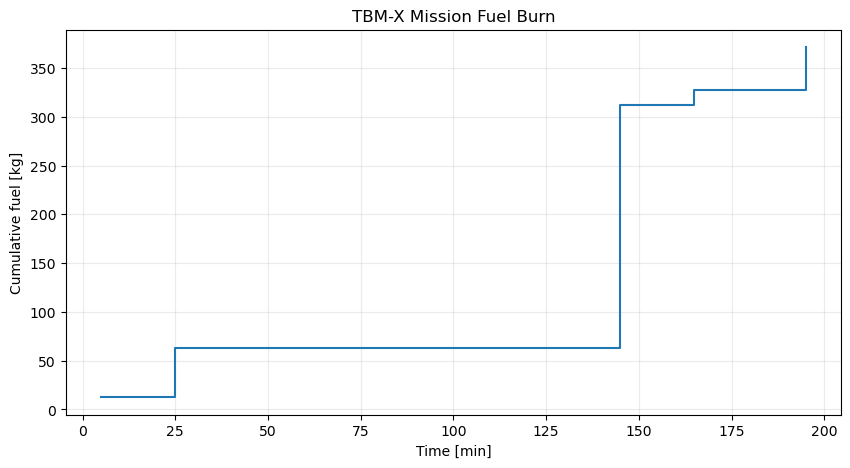

In [2]:
print('Mission time [min]:',segments.duration_min.sum()); print('Distance [NM]:',segments.distance_nm.sum()); print('Fuel burn [kg]:',segments.fuel_burn_kg.sum())
segments['time_end_min']=segments.duration_min.cumsum()
segments['cumulative_fuel_kg']=segments.fuel_burn_kg.cumsum()
plt.figure(figsize=(10,5)); plt.step(segments.time_end_min,segments.cumulative_fuel_kg,where='post'); plt.xlabel('Time [min]'); plt.ylabel('Cumulative fuel [kg]'); plt.title('TBM-X Mission Fuel Burn'); plt.grid(alpha=.25); plt.show()
segments.to_csv(OUT/'mission_segments.csv',index=False)

In [3]:
summary=pd.DataFrame({'metric':['Time [min]','Distance [NM]','Fuel burn [kg]'],'value':[segments.duration_min.sum(),segments.distance_nm.sum(),segments.fuel_burn_kg.sum()]}); summary.to_csv(OUT/'mission_summary.csv',index=False); summary

,metric,value
0,Time [min],195.00
1,Distance [NM],847.50
2,Fuel burn [kg],371.25
